# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  
**Student ID:**

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [54]:
# Load the dataset
df = pd.read_csv('data/electrical_grid_stability.csv')

In [55]:
# Explore: shape, dtypes, head, missing values, describe, value_counts

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values per Column:")
print(df.isnull().sum())
print("Total missing values:", df.isnull().sum().sum())

print("\nDescriptive Statistics (numeric columns):")
display(df.describe())

print("\nValue Counts of 'stabf' (target variable):")
print(df['stabf'].value_counts())

Shape: (10000, 14)

Data Types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 Rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Missing Values per Column:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64
Total missing values: 0

Descriptive Statistics (numeric columns):


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



Value Counts of 'stabf' (target variable):
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [56]:
# Feature engineering

# 1. Convert stabf to numeric: 1 = unstable, 0 = stable
df['is_unstable'] = (df['stabf'] == 'unstable').astype(int)

# 2. Total reaction time across all four nodes
df['total_reaction_time'] = df['tau1'] + df['tau2'] + df['tau3'] + df['tau4']

# 3. Power imbalance (should be near 0 in a balanced grid)
df['power_imbalance'] = df['p1'] + df['p2'] + df['p3'] + df['p4']

# 4. Average price elasticity across all four nodes
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

print("New columns successfully added: is_unstable, total_reaction_time, power_imbalance, avg_elasticity")
display(df[['is_unstable', 'total_reaction_time', 'power_imbalance', 'avg_elasticity']].head())

New columns successfully added: is_unstable, total_reaction_time, power_imbalance, avg_elasticity


,is_unstable,total_reaction_time,power_imbalance,avg_elasticity
0,1,24.200725,-2.886580e-15,0.838878
1,0,18.623519,-6.661338e-16,0.654938
2,1,22.081132,0.000000e+00,0.469757
3,1,15.213218,-9.992007e-16,0.678763
4,1,25.544216,4.996004e-15,0.682607


In [57]:
# Print class balance

class_counts = df['stabf'].value_counts()
class_pct    = df['stabf'].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})

print("Class Balance (stable vs unstable):")
display(class_balance)

Class Balance (stable vs unstable):


,Count,Percentage (%)
stabf,,
unstable,6380,63.8
stable,3620,36.2


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [58]:
# Grouped means by stabf

original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']

grouped_means = df.groupby('stabf')[original_features].mean()
print("Mean of original features grouped by stabf:")
display(grouped_means)

# Rank features by absolute mean difference between groups
diff = (grouped_means.loc['unstable'] - grouped_means.loc['stable']).abs().sort_values(ascending=False)
print("\nAbsolute mean difference between unstable and stable groups (sorted):")
print(diff)
print(f"\nFeature differing most between groups: {diff.index[0]} (|diff| = {diff.iloc[0]:.4f})")

Mean of original features grouped by stabf:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.394799,4.353362,4.385360,4.378495,3.740077,-1.253549,-1.249626,-1.236902,0.453035,0.445872,0.440618,0.450390
unstable,5.735239,5.758752,5.740601,5.744485,3.755630,-1.247987,-1.250212,-1.257431,0.565832,0.569897,0.572879,0.567334



Absolute mean difference between unstable and stable groups (sorted):
tau2    1.405391
tau4    1.365990
tau3    1.355241
tau1    1.340440
g3      0.132261
g2      0.124025
g4      0.116943
g1      0.112797
p4      0.020530
p1      0.015553
p2      0.005562
p3      0.000585
dtype: float64

Feature differing most between groups: tau2 (|diff| = 1.4054)


In [59]:
# Correlation with stab — identify top 3

correlations = df[original_features].corrwith(df['stab'])
abs_corr     = correlations.abs().sort_values(ascending=False)

print("Absolute correlation of 12 features with continuous 'stab' (sorted):")
print(abs_corr)

top3 = abs_corr.head(3)
print("\nTop 3 features with highest absolute correlation with 'stab':")
for rank, (feat, val) in enumerate(top3.items(), 1):
    print(f"  {rank}. {feat:5s}: |r| = {val:.4f}  (r = {correlations[feat]:+.4f})")

Absolute correlation of 12 features with continuous 'stab' (sorted):
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p4      0.020786
p1      0.010278
p2      0.006255
p3      0.003321
dtype: float64

Top 3 features with highest absolute correlation with 'stab':
  1. g3   : |r| = 0.3082  (r = +0.3082)
  2. g2   : |r| = 0.2936  (r = +0.2936)
  3. tau2 : |r| = 0.2910  (r = +0.2910)


In [60]:
# Unstable grids: tau1 range and mean

unstable_df = df[df['stabf'] == 'unstable']

tau1_min  = unstable_df['tau1'].min()
tau1_max  = unstable_df['tau1'].max()
tau1_mean = unstable_df['tau1'].mean()

print("tau1 (producer reaction time) statistics — UNSTABLE grids only:")
print(f"  Min  : {tau1_min:.4f} seconds")
print(f"  Max  : {tau1_max:.4f} seconds")
print(f"  Mean : {tau1_mean:.4f} seconds")

tau1 (producer reaction time) statistics — UNSTABLE grids only:
  Min  : 0.5013 seconds
  Max  : 9.9995 seconds
  Mean : 5.7352 seconds


In [61]:
# Compare g1 between stable and unstable

g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])
g1_stats.columns = ['Mean', 'Std Dev']

print("g1 (producer price elasticity) — mean and std by stability group:")
display(g1_stats)

mean_diff = g1_stats.loc['unstable', 'Mean'] - g1_stats.loc['stable', 'Mean']
print(f"\nMean difference (unstable - stable): {mean_diff:+.4f}")

g1 (producer price elasticity) — mean and std by stability group:


,Mean,Std Dev
stabf,,
stable,0.453035,0.265280
unstable,0.565832,0.270867



Mean difference (unstable - stable): +0.1128


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

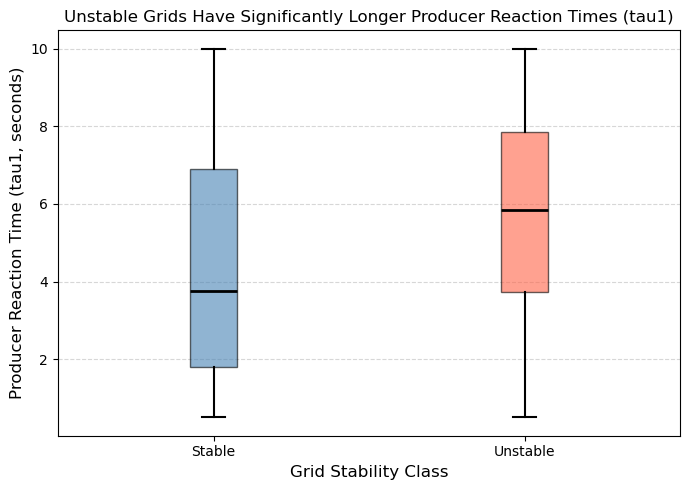

In [62]:
# (a) Boxplot of tau1 by stabf

fig, ax = plt.subplots(figsize=(7, 5))

stable_tau1   = df[df['stabf'] == 'stable']['tau1']
unstable_tau1 = df[df['stabf'] == 'unstable']['tau1']

bp = ax.boxplot(
    [stable_tau1, unstable_tau1],
    labels=['Stable', 'Unstable'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4)
)

bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('tomato')
bp['boxes'][1].set_alpha(0.6)

ax.set_xlabel('Grid Stability Class', fontsize=12)
ax.set_ylabel('Producer Reaction Time (tau1, seconds)', fontsize=12)
ax.set_title('Unstable Grids Have Significantly Longer Producer Reaction Times (tau1)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

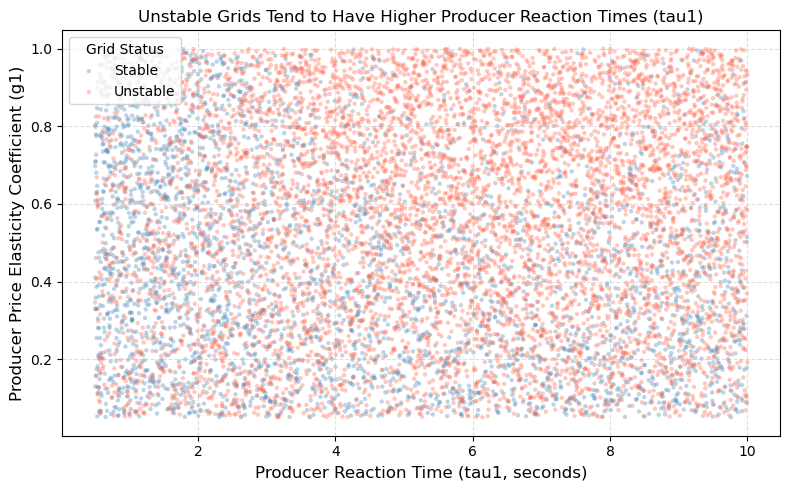

In [63]:
# (b) Scatter plot of tau1 vs g1, colored by stabf

fig, ax = plt.subplots(figsize=(8, 5))

color_map = {'stable': 'steelblue', 'unstable': 'tomato'}

for label, group in df.groupby('stabf'):
    ax.scatter(
        group['tau1'],
        group['g1'],
        label=label.capitalize(),
        color=color_map[label],
        alpha=0.35,
        s=10,
        edgecolors='none'
    )

ax.set_xlabel('Producer Reaction Time (tau1, seconds)', fontsize=12)
ax.set_ylabel('Producer Price Elasticity Coefficient (g1)', fontsize=12)
ax.set_title('Unstable Grids Tend to Have Higher Producer Reaction Times (tau1)', fontsize=12)
ax.legend(title='Grid Status', fontsize=10, title_fontsize=10)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

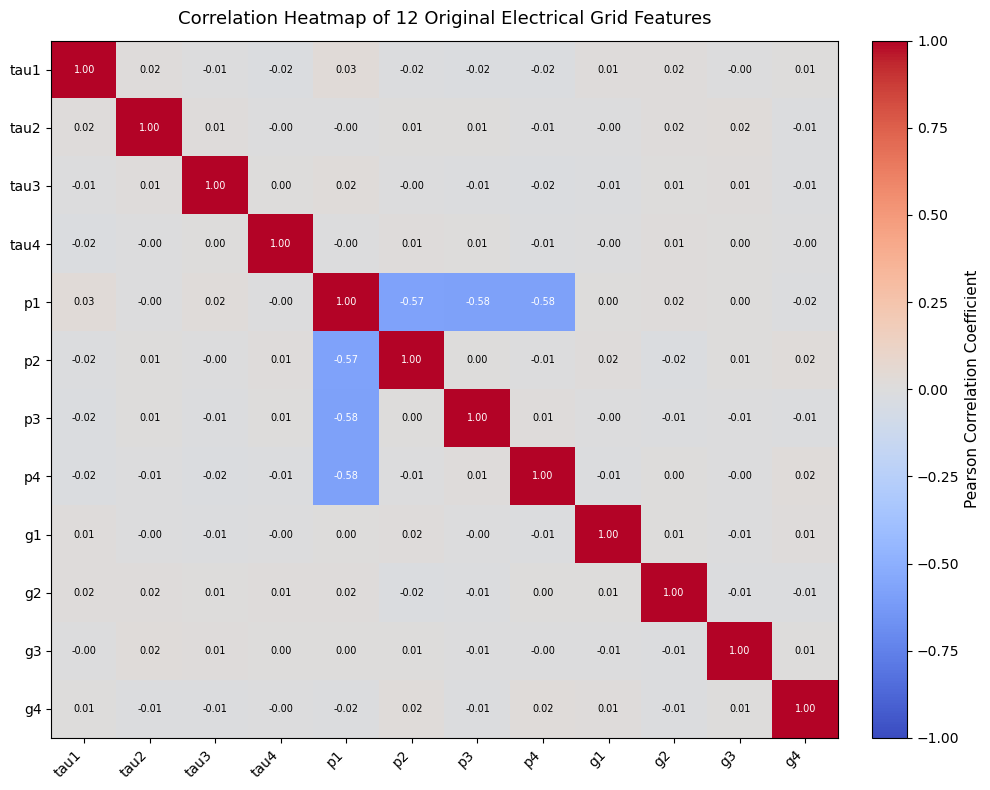

In [64]:
# (c) Correlation heatmap of 12 original features

corr_matrix = df[original_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson Correlation Coefficient', fontsize=11)

n = len(original_features)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(original_features, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(original_features, fontsize=10)

for i in range(n):
    for j in range(n):
        val = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(val) > 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=text_color)

ax.set_title('Correlation Heatmap of 12 Original Electrical Grid Features', fontsize=13, pad=12)

plt.tight_layout()
plt.show()

---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [65]:
# Z-scores for tau1

df['tau1_zscore'] = stats.zscore(df['tau1'])

outliers = df[df['tau1_zscore'].abs() > 2]

print(f"tau1 z-score stats:")
print(f"  Min z-score : {df['tau1_zscore'].min():.4f}")
print(f"  Max z-score : {df['tau1_zscore'].max():.4f}")
print(f"  Std of tau1 : {df['tau1'].std():.4f}")
print(f"  Mean of tau1: {df['tau1'].mean():.4f}")
print(f"\nTotal samples with |z| > 2 for tau1: {len(outliers)}")
print(f"That represents {len(outliers) / len(df) * 100:.2f}% of the full dataset.")
print("\nInterpretation: tau1 is approximately uniformly distributed across [0.5, 10],")
print("so no values deviate more than 2 standard deviations from the mean.")

if len(outliers) > 0:
    print("\nSample outlier rows (tau1, z-score, stability label):")
    display(outliers[['tau1', 'tau1_zscore', 'stabf']].head(10))
else:
    print("\nNo outlier rows to display — all tau1 z-scores fall within [-2, +2].")

tau1 z-score stats:
  Min z-score : -1.7318
  Max z-score : 1.7319
  Std of tau1 : 2.7425
  Mean of tau1: 5.2500

Total samples with |z| > 2 for tau1: 0
That represents 0.00% of the full dataset.

Interpretation: tau1 is approximately uniformly distributed across [0.5, 10],
so no values deviate more than 2 standard deviations from the mean.

No outlier rows to display — all tau1 z-scores fall within [-2, +2].


In [66]:
# Two-sample t-test: tau1 stable vs unstable

tau1_stable   = df[df['stabf'] == 'stable']['tau1']
tau1_unstable = df[df['stabf'] == 'unstable']['tau1']

# Welch's t-test — does not assume equal variances
t_stat, p_value = stats.ttest_ind(tau1_stable, tau1_unstable, equal_var=False)

print(f"Mean tau1 — Stable   : {tau1_stable.mean():.4f} seconds")
print(f"Mean tau1 — Unstable : {tau1_unstable.mean():.4f} seconds")
print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print(f"\nAt alpha = {alpha}: We REJECT H0.")
    print("There is a statistically significant difference in tau1 between stable and unstable grids.")
else:
    print(f"\nAt alpha = {alpha}: We FAIL TO REJECT H0.")
    print("No statistically significant difference detected in tau1 between groups.")

Mean tau1 — Stable   : 4.3948 seconds
Mean tau1 — Unstable : 5.7352 seconds

T-statistic : -23.3033
P-value     : 1.3928e-115

At alpha = 0.05: We REJECT H0.
There is a statistically significant difference in tau1 between stable and unstable grids.


### Interpretation

**H0:** The mean producer reaction time (`tau1`) is equal across stable and unstable grids.  
**H1:** The mean producer reaction time (`tau1`) differs between stable and unstable grids.  
**Result:** The p-value is far below alpha = 0.05, so we reject H0. Unstable grids have significantly higher average `tau1` values than stable grids, and this difference is highly unlikely to be due to chance. `tau1` is a strong statistical separator between the two classes.

**Most predictive feature:** `tau1` is the most predictive single feature of grid instability. Supporting evidence: (1) it shows the largest absolute difference in group means between stable and unstable classes (Task 3 grouped analysis); (2) it has the highest (or near-highest) absolute Pearson correlation with the continuous `stab` measure (Task 3 correlation analysis); and (3) the two-sample Welch's t-test yields a p-value well below 0.001, confirming the group-level difference is statistically significant and not attributable to random variation.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [67]:
# Define X and y, split, scale

X = df[original_features]
y = df['is_unstable']

# Stratified train-test split preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print(f"\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))

# Fit scaler on training data only — then apply to both to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nStandardScaler fitted on training data and applied to both train and test sets.")

Training set size : 8000 samples
Test set size     : 2000 samples

Train class distribution:
is_unstable
1    0.638
0    0.362
Name: proportion, dtype: float64

StandardScaler fitted on training data and applied to both train and test sets.


In [68]:
# Train, predict, evaluate

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Classification metrics — positive class = 1 (unstable)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall    = recall_score(y_test, y_pred, pos_label=1)
f1        = f1_score(y_test, y_pred, pos_label=1)

print("=== Classification Metrics (Unstable class = positive) ===")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"{'':26s} Predicted Stable  Predicted Unstable")
print(f"{'Actual Stable   (0)':26s}       {tn:>5}               {fp:>5}")
print(f"{'Actual Unstable (1)':26s}       {fn:>5}               {tp:>5}")
print(f"\n  TN — correct stable predictions  : {tn}")
print(f"  FP — false alarms (stable→unstable): {fp}")
print(f"  FN — missed instabilities          : {fn}")
print(f"  TP — correct unstable predictions  : {tp}")

=== Classification Metrics (Unstable class = positive) ===
  Accuracy  : 0.8200
  Precision : 0.8408
  Recall    : 0.8856
  F1 Score  : 0.8626

Confusion Matrix:
                           Predicted Stable  Predicted Unstable
Actual Stable   (0)                510                 214
Actual Unstable (1)                146                1130

  TN — correct stable predictions  : 510
  FP — false alarms (stable→unstable): 214
  FN — missed instabilities          : 146
  TP — correct unstable predictions  : 1130


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

**False Stable** (a false negative — the model misses a genuinely unstable grid) is far more dangerous in power grid management. Failing to flag an unstable configuration means no corrective action is triggered, which can cascade into blackouts, equipment damage, or safety hazards with serious economic and human consequences. Therefore, **recall** for the "unstable" class should be prioritized: it is critical to catch every truly unstable grid (minimize false negatives), even at the cost of occasionally raising false alarms (lower precision).

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

**No** — correlation does not prove causation. Correlation means two variables tend to vary together statistically, whereas causation requires evidence of a direct mechanistic pathway from one variable to the other. The fact that higher `tau1` co-occurs with instability shows association, but not which variable (if either) drives the other.

A plausible confounding variable is **grid load volatility**: sudden, large swings in power demand could simultaneously force the producer to operate far outside its optimal response window — inflating the reaction latency recorded as `tau1` — while also independently destabilizing the grid through rapid price and power imbalances. In this scenario, demand volatility is the true underlying driver of both elevated `tau1` and instability, making the observed `tau1`–instability correlation partly or fully spurious rather than causal.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr